# training set sample

In [37]:
import os
import shutil
import random
import csv
from pathlib import Path

def create_train_set(source_dir, target_dir, csv_filename, sample_size_per_folder=10):
    
    source_path = Path(source_dir)
    target_path = Path(target_dir)
    
    target_path.mkdir(parents=True, exist_ok=True)
    
    with open(csv_filename, mode='w', newline='', encoding='utf-8') as csv_file:
        writer = csv.writer(csv_file)
        writer.writerow(['original_folder', 'original_filename', 'new_filename'])
        
        for subfolder in source_path.iterdir():
            if subfolder.is_dir():
                folder_name = subfolder.name
                
                json_files = list(subfolder.glob('*.json'))
                
                if not json_files:
                    continue
                
                n_samples = min(sample_size_per_folder, len(json_files))
                
                sampled_files = random.sample(json_files, n_samples)
                
                for file_path in sampled_files:
                    original_filename = file_path.name
                    
                    new_filename = f"{folder_name}_{original_filename}"
                    target_file_path = target_path / new_filename
                    
                    shutil.copy2(file_path, target_file_path)
                    
                    writer.writerow([folder_name, original_filename, new_filename])
                    
    print(f"✅ Training set created successfully in '{target_dir}'!")
    print(f"✅ Metadata saved to '{csv_filename}'.")

SOURCE_DIRECTORY = '/home/jmsb00nd/Documents/auto-heuristics/benchmarks'
TARGET_DIRECTORY = 'training-set'
CSV_OUTPUT_FILE = 'training-set_metadata.csv'

# Set how many circuits you want to sample from EACH folder
SAMPLE_SIZE = 5 

# Run the function
create_train_set(SOURCE_DIRECTORY, TARGET_DIRECTORY, CSV_OUTPUT_FILE, SAMPLE_SIZE)

✅ Training set created successfully in 'training-set'!
✅ Metadata saved to 'training-set_metadata.csv'.


# baseline training set

In [38]:
import pandas as pd
import numpy as np
from pathlib import Path

def augment_metadata_with_baselines(input_csv, output_csv, results_dir):
    methods = ['sabre', 'qmap', 'pytket', 'cirq']
    
    print(f"Loading dataset metadata from '{input_csv}'...")
    df = pd.read_csv(input_csv)
    
    # Initialize new columns with NaN
    for method in methods:
        df[f"{method}_sherbrooke_swaps_trivial"] = np.nan
        df[f"{method}_sherbrooke_depth_trivial"] = np.nan

    cache = {}

    def get_baseline_data(folder, method):
        if folder not in cache:
            cache[folder] = {}
        
        if method not in cache[folder]:
            csv_path = Path(results_dir) / folder / f"{method}.csv"
            mapping = {}
            
            if csv_path.exists():
                try:
                    baseline_df = pd.read_csv(csv_path)
                    baseline_df['filename'] = baseline_df['file_path'].apply(lambda x: Path(str(x)).name)
                    
                    for _, row in baseline_df.iterrows():
                        mapping[row['filename']] = {
                            'swaps': row['sherbrooke_swaps_trivial'],
                            'depth': row['sherbrooke_depth_trivial']
                        }
                except Exception as e:
                    print(f"⚠️ Warning: Could not read {csv_path}. Error: {e}")
            else:
                print(f"⚠️ Warning: File not found -> {csv_path}")
                
            cache[folder][method] = mapping
            
        return cache[folder][method]

    print("Fetching baseline results and mapping them to the dataset...")
    
    for idx, row in df.iterrows():
        folder = row['original_folder']
        filename = row['original_filename']
        
        for method in methods:
            method_data = get_baseline_data(folder, method)
            
            if filename in method_data:
                df.at[idx, f"{method}_sherbrooke_swaps_trivial"] = method_data[filename]['swaps']
                df.at[idx, f"{method}_sherbrooke_depth_trivial"] = method_data[filename]['depth']

    metric_columns = []
    for method in methods:
        swaps_col = f"{method}_sherbrooke_swaps_trivial"
        depth_col = f"{method}_sherbrooke_depth_trivial"
        
        df[swaps_col] = pd.to_numeric(df[swaps_col], errors='coerce')
        df[depth_col] = pd.to_numeric(df[depth_col], errors='coerce')
        
        metric_columns.extend([swaps_col, depth_col])

    # Save the updated dataframe
    df.to_csv(output_csv, index=False)
    print(f"\n✅ Augmented dataset saved to '{output_csv}'!\n")

    df_clean = df.dropna(subset=metric_columns)
    
    for method in methods:
        mean_swaps = df_clean[f"{method}_sherbrooke_swaps_trivial"].mean()
        mean_depth = df_clean[f"{method}_sherbrooke_depth_trivial"].mean()
        
        print(f"Method: {method.upper()}")
        print(f"  Mean Swaps: {mean_swaps:.2f}")
        print(f"  Mean Depth: {mean_depth:.2f}")
        print("-" * 35)


INPUT_METADATA_CSV = '/home/jmsb00nd/Documents/auto-heuristics/benchmarks/training-set_metadata.csv'          
OUTPUT_METADATA_CSV = 'train_set_with_baselines.csv'   
RESULTS_BASE_DIR = '/home/jmsb00nd/Documents/auto-heuristics/baselines/results'
augment_metadata_with_baselines(INPUT_METADATA_CSV, OUTPUT_METADATA_CSV, RESULTS_BASE_DIR)

Loading dataset metadata from '/home/jmsb00nd/Documents/auto-heuristics/benchmarks/training-set_metadata.csv'...
Fetching baseline results and mapping them to the dataset...


/tmp/ipykernel_417114/847208573.py:55: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '49' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[idx, f"{method}_sherbrooke_swaps_trivial"] = method_data[filename]['swaps']
/tmp/ipykernel_417114/847208573.py:56: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '74' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[idx, f"{method}_sherbrooke_depth_trivial"] = method_data[filename]['depth']
/tmp/ipykernel_417114/847208573.py:55: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '8571' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[idx, f"{method}_sherbrooke_swaps_trivia


✅ Augmented dataset saved to 'train_set_with_baselines.csv'!

Method: SABRE
  Mean Swaps: 4523.64
  Mean Depth: 2133.60
-----------------------------------
Method: QMAP
  Mean Swaps: 7230.40
  Mean Depth: 2013.28
-----------------------------------
Method: PYTKET
  Mean Swaps: 5191.56
  Mean Depth: 2762.44
-----------------------------------
Method: CIRQ
  Mean Swaps: 4569.60
  Mean Depth: 2144.96
-----------------------------------


# Baseline result training set

In [39]:
import pandas as pd

# Load CSV
df = pd.read_csv("/home/jmsb00nd/Documents/auto-heuristics/train_set_with_baselines.csv")

# Ensure numeric columns (coerce errors like empty fields to NaN)
numeric_cols = df.columns.drop(
    ["original_folder", "original_filename", "new_filename"]
)
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

# Define methods
methods = ["sabre", "qmap", "pytket", "cirq"]

results = {}

for method in methods:
    swap_col = f"{method}_sherbrooke_swaps_trivial"
    depth_col = f"{method}_sherbrooke_depth_trivial"
    
    mean_swaps = df[swap_col].mean()
    mean_depth = df[depth_col].mean()
    
    results[method] = {
        "mean_swaps": mean_swaps,
        "mean_depth": mean_depth
    }

# Convert to DataFrame for cleaner output
mean_df = pd.DataFrame(results).T
print(mean_df)

        mean_swaps  mean_depth
sabre      4523.64     2133.60
qmap       7230.40     2013.28
pytket     5191.56     2762.44
cirq       4569.60     2144.96


# baseline qasmbench-large

In [4]:
import pandas as pd
import os

directory = "/home/jmsb00nd/Documents/auto-heuristics/baselines/results/qasmbench-large"
files = ["sabre.csv", "cirq.csv", "qmap.csv", "pytket.csv"]
columns_to_mean = ["sherbrooke_swaps_trivial", "sherbrooke_depth_trivial"]

summary_data = []

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            means = df[columns_to_mean].mean().to_dict()
            means['source_file'] = file_name
            summary_data.append(means)
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

summary_df = pd.DataFrame(summary_data)
cols = ['source_file'] + columns_to_mean
summary_df = summary_df[cols]
print("\nPreview of the data:")
print(summary_df)

Error processing cirq.csv: Could not convert ['148error63166649421796224104error3864541465433689914419010672error2060'
 '263error9339207410039112207152error66958049361524211197344188100error4250'] to numeric

Preview of the data:
  source_file  sherbrooke_swaps_trivial  sherbrooke_depth_trivial
0   sabre.csv                705.727273               1068.136364
1    qmap.csv                706.590909               1021.500000
2  pytket.csv                794.863636               1140.090909


In [3]:
df = pd.read_csv("/home/jmsb00nd/Documents/auto-heuristics/autoheuristics_results/queko-bss-16qbt_ibm_sherbrooke_trivial.csv")
mean_swap = df["swap_count"].mean()
print("mean swaps : ", mean_swap)
mean_depth = df["final_depth"].mean()
print("mean depth : ", mean_depth)

mean swaps :  923.9222222222222
mean depth :  1282.911111111111


# baseline queko 16qbt

In [5]:
import pandas as pd
import os

directory = "/home/jmsb00nd/Documents/auto-heuristics/baselines/results/queko-bss-16qbt"
files = ["sabre.csv", "cirq.csv", "qmap.csv", "pytket.csv"]
columns_to_mean = ["sherbrooke_swaps_trivial", "sherbrooke_depth_trivial"]

summary_data = []

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            means = df[columns_to_mean].mean().to_dict()
            means['source_file'] = file_name
            summary_data.append(means)
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

summary_df = pd.DataFrame(summary_data)
cols = ['source_file'] + columns_to_mean
summary_df = summary_df[cols]
print("\nPreview of the data:")
print(summary_df)


Preview of the data:
  source_file  sherbrooke_swaps_trivial  sherbrooke_depth_trivial
0   sabre.csv                953.100000               1323.911111
1    cirq.csv               1074.388889               2042.233333
2    qmap.csv               1265.177778               1420.700000
3  pytket.csv               1176.244444               1483.433333


# plots

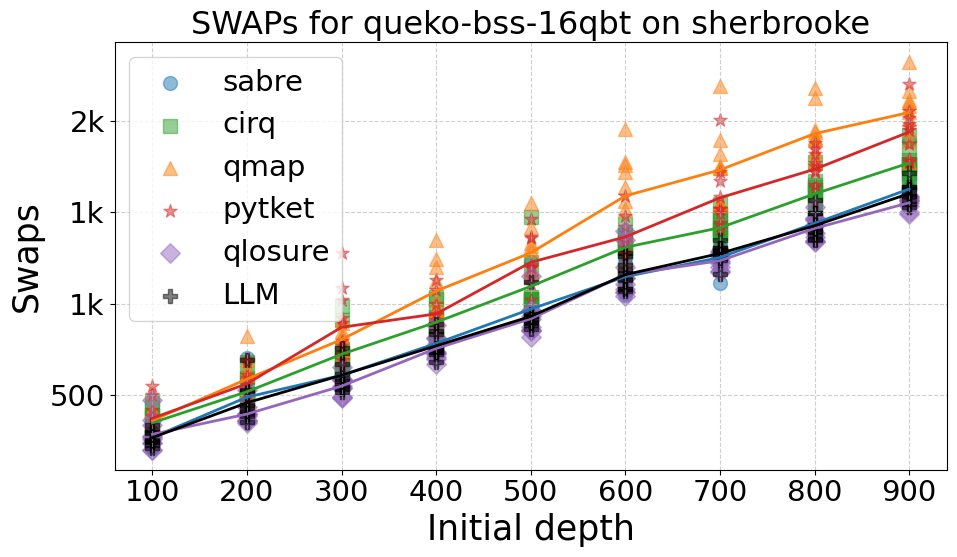

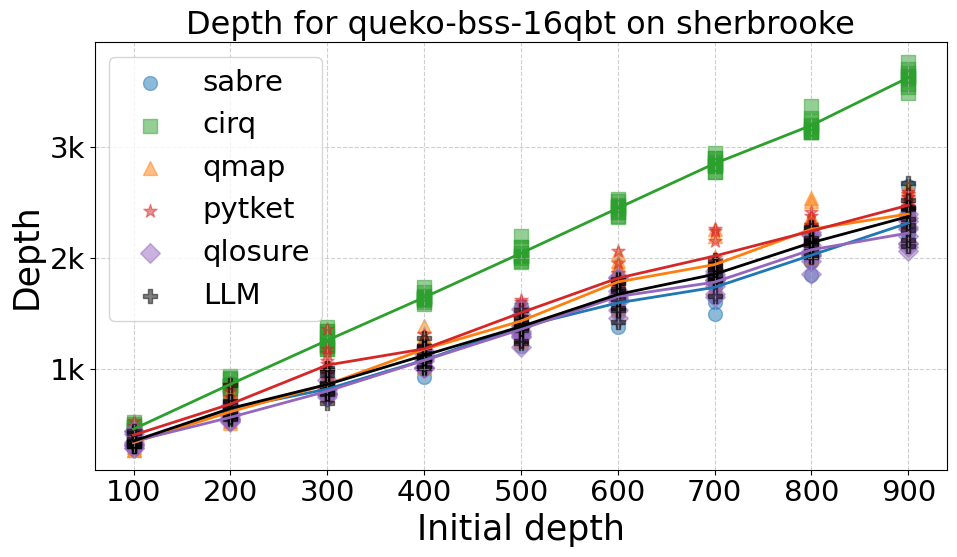

In [3]:
import os
import sys
import matplotlib.pyplot as plt
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "queko-bss-16qbt"
BACKEND_NAME = "ibm_sherbrooke"

paths = {
    "sabre": f"./baselines/results/{BENCHMARK}/sabre.csv",
    "cirq": f"./baselines/results/{BENCHMARK}/cirq.csv",
    "qmap": f"./baselines/results/{BENCHMARK}/qmap.csv",
    "pytket": f"./baselines/results/{BENCHMARK}/pytket.csv",
    "qlosure": f"./results/stats/{BENCHMARK}_{BACKEND_NAME}_trivial.csv",
    "LLM" : f"./autoheuristics_results/{BENCHMARK}_{BACKEND_NAME}_trivial.csv"
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path) if name in ["qlosure", "LLM"] else group_by_initial_depth_baseline(
            path, backend=plot_backend, init_mapping_method="trivial")
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

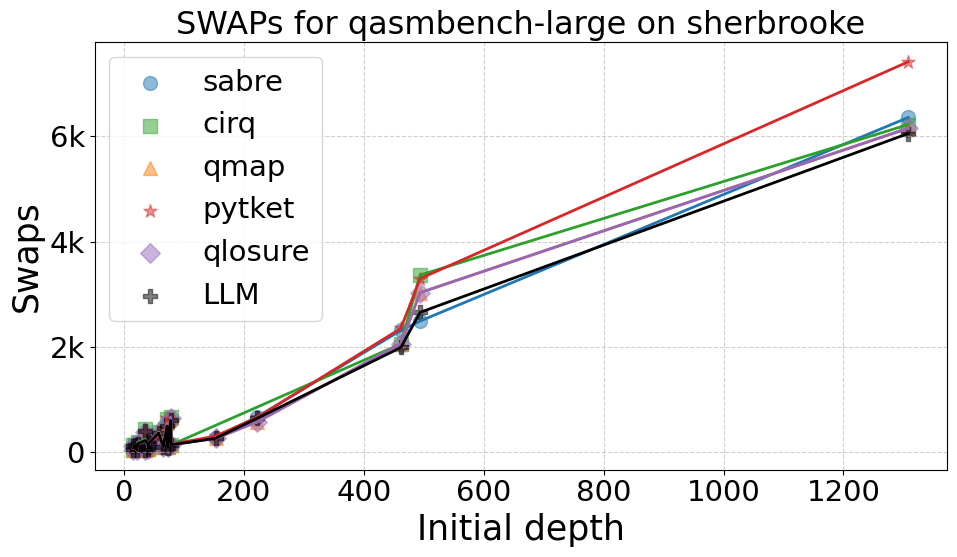

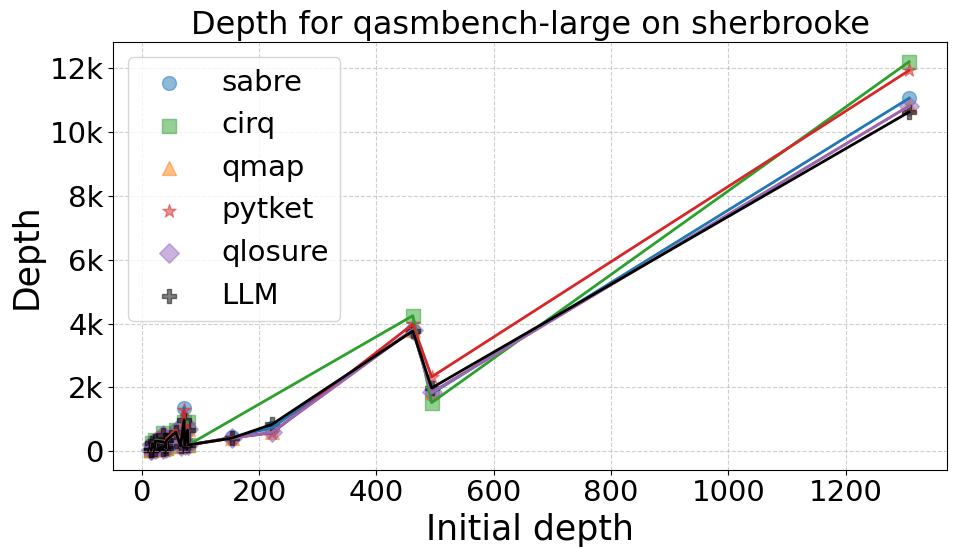

In [4]:
import os
import sys
import matplotlib.pyplot as plt
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "qasmbench-large"
BACKEND_NAME = "ibm_sherbrooke"

paths = {
    "sabre": f"./baselines/results/{BENCHMARK}/sabre.csv",
    "cirq": f"./baselines/results/{BENCHMARK}/cirq.csv",
    "qmap": f"./baselines/results/{BENCHMARK}/qmap.csv",
    "pytket": f"./baselines/results/{BENCHMARK}/pytket.csv",
    "qlosure": f"./results/stats/{BENCHMARK}_{BACKEND_NAME}_trivial.csv",
    "LLM" : f"./autoheuristics_results/{BENCHMARK}_{BACKEND_NAME}_trivial.csv"
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path) if name in ["qlosure", "LLM"] else group_by_initial_depth_baseline(
            path, backend=plot_backend, init_mapping_method="trivial")
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

# qlosure qasmbench-large

In [2]:
import pandas as pd

# Load the CSV file
df = pd.read_csv('/home/jmsb00nd/Documents/auto-heuristics/results/stats/qasmbench-large_ibm_sherbrooke_trivial.csv')

# Calculate the mean for swaps and depth
mean_swaps = df['swap_count'].mean()
mean_depth = df['final_depth'].mean()

# Print the results
print(f"Mean Swap Count: {mean_swaps:.2f}")
print(f"Mean Final Depth: {mean_depth:.2f}")

Mean Swap Count: 706.59
Mean Final Depth: 1021.50


In [9]:
import pandas as pd

# Load the CSV file
df = pd.read_csv('/home/jmsb00nd/Documents/auto-heuristics/baselines/results/qasmbench-large/pytket.csv')

# Calculate the mean for swaps and depth
mean_swaps = df['sherbrooke_swaps_trivial'].mean()
mean_depth = df['sherbrooke_depth_trivial'].mean()

# Print the results
print(f"Mean Swap Count: {mean_swaps:.2f}")
print(f"Mean Final Depth: {mean_depth:.2f}")

Mean Swap Count: 794.86
Mean Final Depth: 1140.09
